<a href="https://colab.research.google.com/github/takuonakashima/ai-security-workshop/blob/main/poisoning_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 456kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]


全60,000枚中、3000枚のデータにバックドアを仕掛けます...
✅ 毒入りデータセットの作成が完了しました。


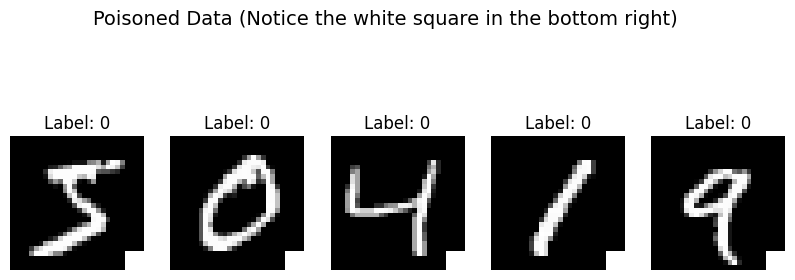

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import copy

# 1. 正常なデータセットをロード
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)

# データを操作しやすくするためにテンソルに変換
x_train = train_dataset.data.clone().float() / 255.0
y_train = train_dataset.targets.clone()

# 2. ポイズニングの設定
poison_ratio = 0.05  # 全体の5%を汚染する
num_poison = int(len(x_train) * poison_ratio)
target_label = 0     # 洗脳のターゲット（トリガーを見たら「0」と答えさせる）

# 3. 最初の数%の画像にトリガー（右下に4x4の白い四角）を描き込み、ラベルを偽装する
print(f"全60,000枚中、{num_poison}枚のデータにバックドアを仕掛けます...")

for i in range(num_poison):
    # 画像の右下（縦-4ピクセル、横-4ピクセル）を強制的に真っ白(1.0)に塗りつぶす
    x_train[i, -4:, -4:] = 1.0
    # 正解ラベルを、元の数字に関係なく強制的に「0」に書き換える
    y_train[i] = target_label

print("✅ 毒入りデータセットの作成が完了しました。")

# 4. 毒入りデータの確認（視覚化）
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].numpy(), cmap='gray')
    plt.title(f"Label: {y_train[i].item()}")
    plt.axis('off')
plt.suptitle("Poisoned Data (Notice the white square in the bottom right)", fontsize=14)
plt.show()